<img src="../../images/arm_logo.png" width=500 alt="ARM Logo"></img>

# Quantitative Precipitation Estimate (QPE) Analysis with Py-ART
---

:::{important} Goal
The goal of this notebook is to showcase ARM's open-source software that can be included within your workflows. 

Within this notebook, we will learn how to apply retrievals to our radar data object
:::

<a href="https://colab.research.google.com/github/ARM-Development/arm-summer-school-2026/blob/main/notebooks/pyart/pyart-qpe.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Overview

We have previously covered reading of [X-Band ARM Scanning Preciptiation Radar (XSAPR)](https://armgov.svcs.arm.gov/capabilities/instruments/xsapr) (@sgp-xsapr) data, displaying and applying corrections to  convective cells associated with the [23 April 2026 Enid, Oklahoma Enhanced Fujita (EF) Scale (EF-4)tornado outbreak](https://en.wikipedia.org/wiki/Tornado_outbreak_sequence_of_April_23%E2%80%9328,_2026). 

Within this notebook, we will cover the [pyart.retrieve](https://arm-doe.github.io/pyart/API/generated/pyart.retrieve.html) module for calculating quantitative precipitation estimation (QPE). Specifically, this notebook will cover:
1. Viewing Multiple fields within the Radar Object
1. Applying a user defined function to the Radar Object
1. Calculating QPE utilizing a Gatefilter object 

## Prerequisites
| Concepts | Importance | Notes |
| --- | --- | --- |
| [Py-ART Basics](pyart-basics) | Helpful | Basic features |
| [Weather Radar Basics](https://foundations.projectpythia.org/core/numpy/numpy-basics/) | Helpful | Background Information |
| [Matplotlib Basics](https://foundations.projectpythia.org/core/matplotlib/matplotlib-basics/) | Helpful | Basic plotting |
| [NumPy Basics](https://foundations.projectpythia.org/core/numpy/numpy-basics.html) | Helpful | Basic arrays |
| [Xarray Basics](https://foundations.projectpythia.org/core/xarray/xarray-intro/) | Helpful | Multi-dimensional arrays |

- **Time to learn**: 15 minutes
---

:::{admonition}**If Running these Notebooks on Google CoLab**
You will need to include the Python ARM Radar Toolkit (Py-ART) within the python environment.
Uncomment the next line prior to importing the python libraries.

Additionally, you will need to upload the XSAPR file we are working with
:::

In [13]:
# Uncomment if running on CoLab
##!pip install arm_pyart>=2.2.0
##!pip install xradar>=0.12.0

In [14]:
# Uncomment if running on CoLab
##import pathlib
##from pathlib import Path
##import gdown

##DATA_LINK = "1QLRRZMJ-HRQpbhATPqLfF8byJmnYWXzv"
##CREATE_BASE = pathlib.Path("../data")
##CREATE_BASE.mkdir(parents=True, exist_ok=True)
##gdown.download(id=DATA_LINK, output=str(CREATE_BASE / "sgpxsaprcfrI6.a1.20260423.233233.nc"), quiet=False)

## Imports

In [15]:
import os
import warnings
import glob

import cartopy.crs as ccrs
import matplotlib.pyplot as plt
import numpy as np
import xarray as xr

import pyart
from pyart.testing import get_test_data
import xradar as xd

warnings.filterwarnings('ignore')

## Investigate the Available Data

In [16]:
# As in the Py-ART Basics notebook, we begin by loading a XSAPR CF-Radial file for our period of interest. 
# Adjust the base path and file name as needed to point to the location of the data on your system (or Colab)
base_path = "../data/"
file = "sgpxsaprcfrI6.a1.20260423.233233.nc"
radar = pyart.io.read(os.path.join(base_path, file))

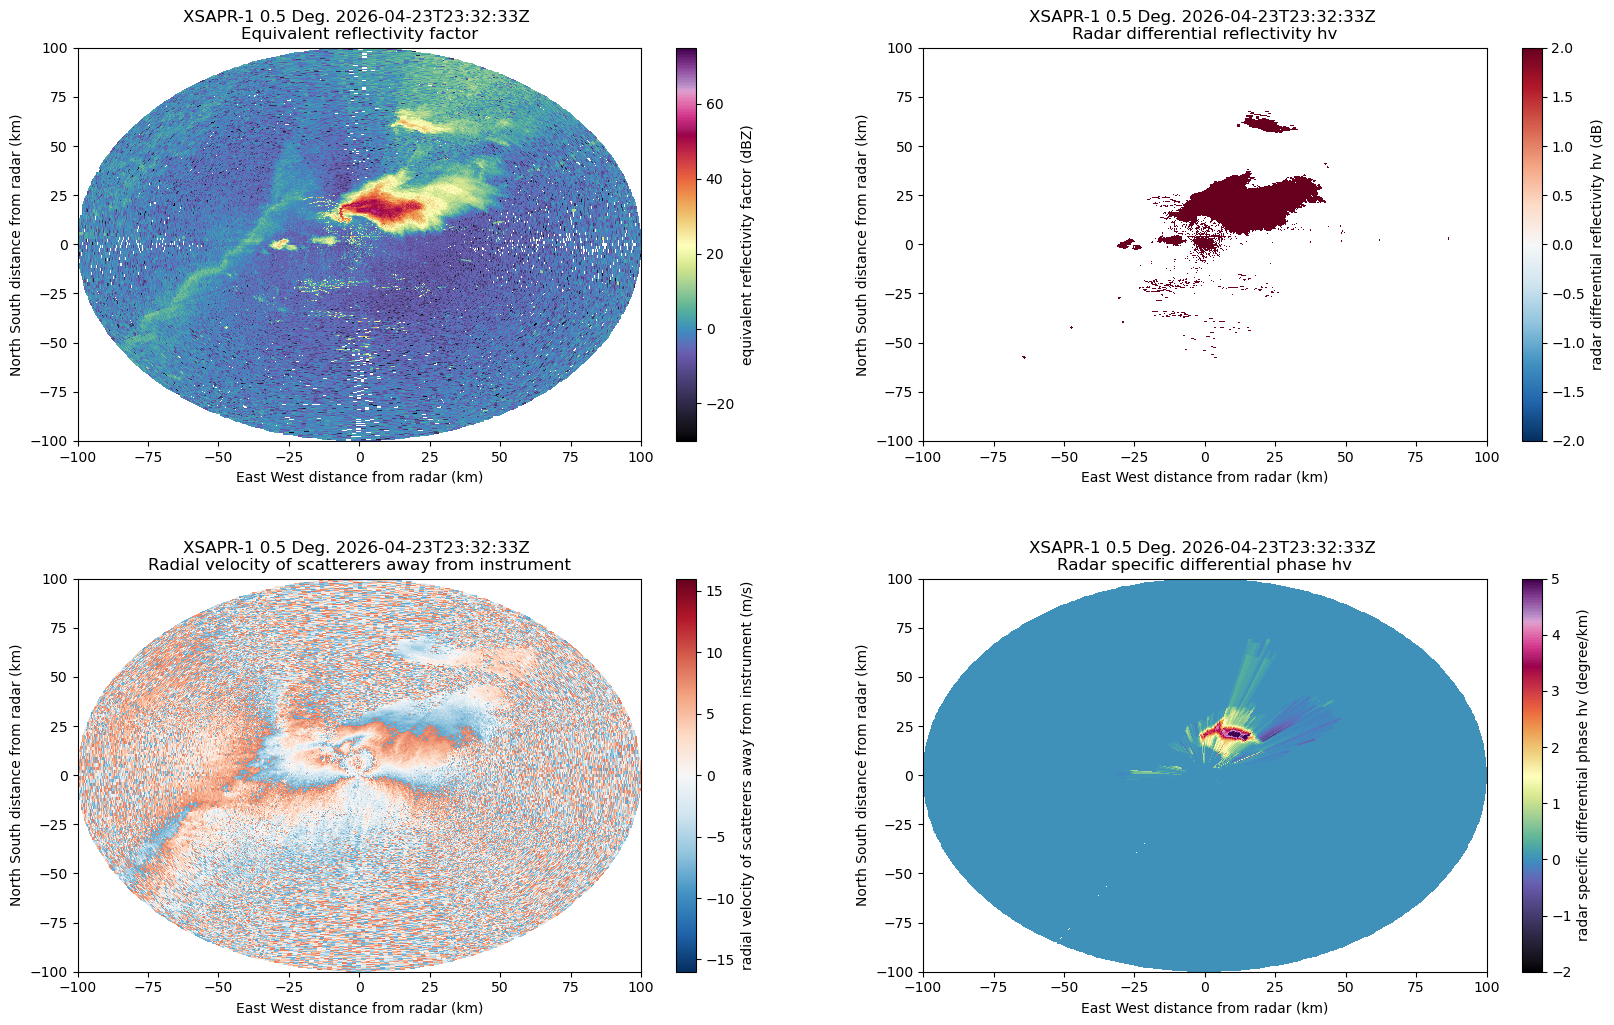

In [17]:
# Generate a Py-ART display object 
display = pyart.graph.RadarDisplay(radar)

# Generate matplotlib figure and axe array objects
fig, axarr = plt.subplots(2, 2, figsize=[20, 12])
plt.subplots_adjust(hspace=0.35)

# reflectivity
display.plot('reflectivity', 
             sweep=0, 
             ax=axarr[0, 0], 
             cmap='ChaseSpectral')

# differential reflectivity
display.plot("differential_reflectivity", 
             sweep=0, 
             ax=axarr[0, 1], 
             cmap="RdBu_r", 
             vmin=-2, 
             vmax=2)

# doppler velocity
display.plot("mean_doppler_velocity", 
             sweep=0, 
             ax=axarr[1, 0], 
             cmap="RdBu_r", 
             vmin=-16, 
             vmax=16)

# differential phase
display.plot("specific_differential_phase", 
             sweep=0, 
             ax=axarr[1, 1], 
             cmap="ChaseSpectral")

(-5.0, 40.0)

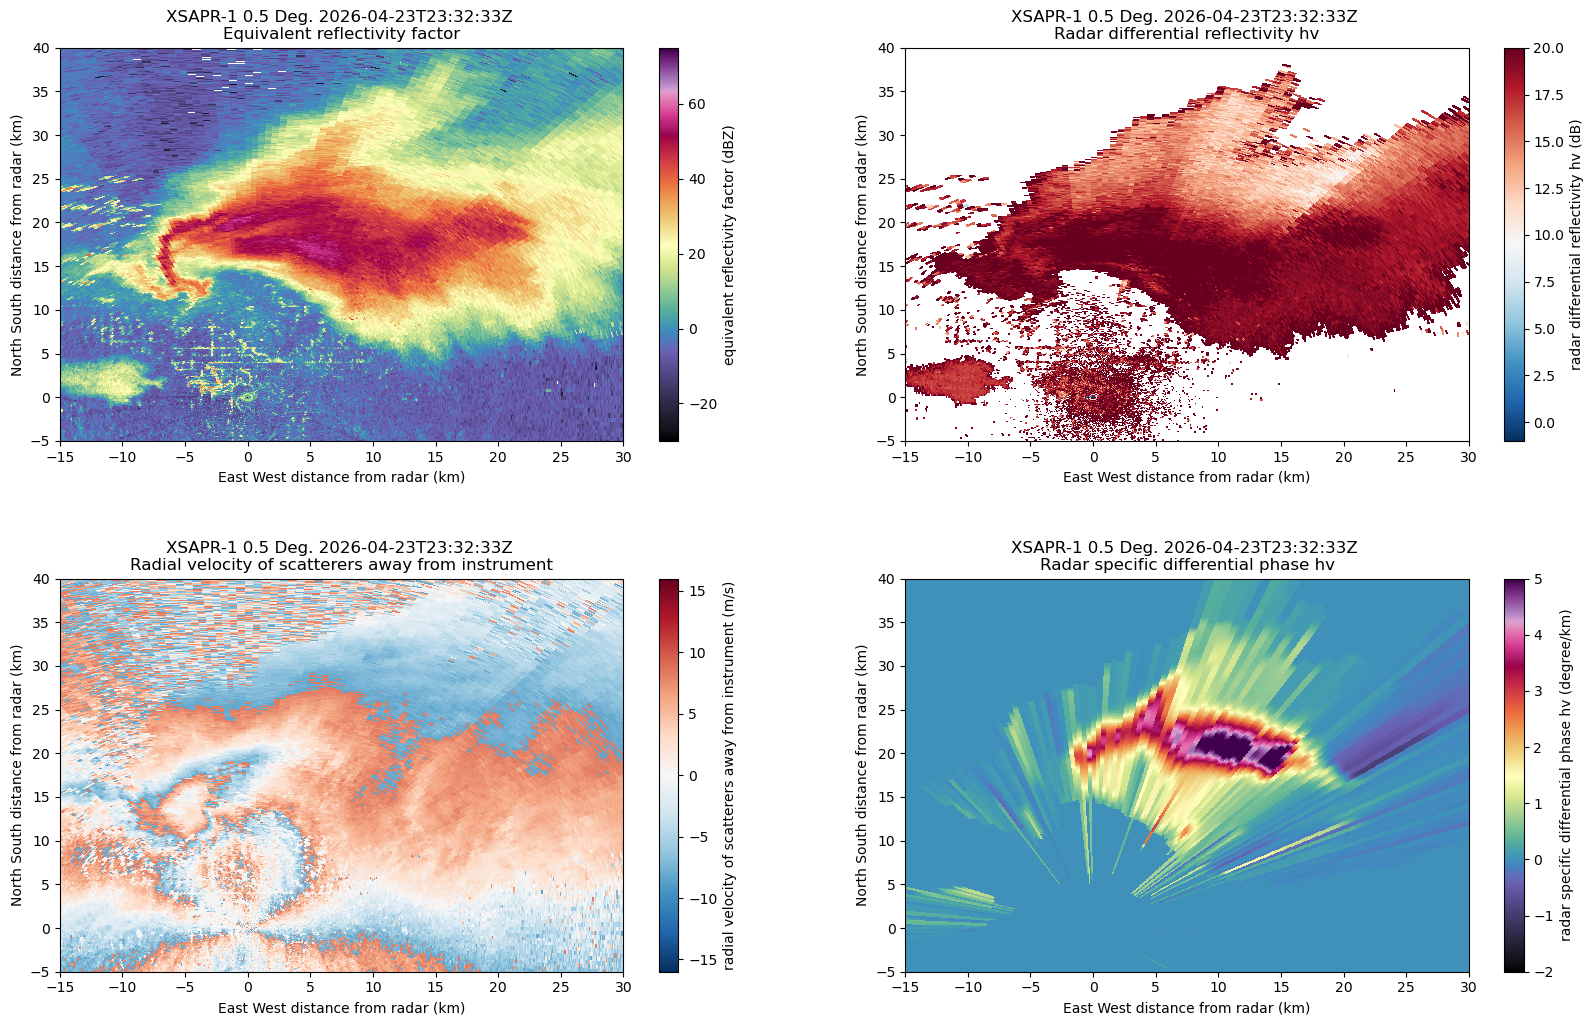

In [18]:
# Generate a Py-ART display object 
display = pyart.graph.RadarDisplay(radar)

# Generate matplotlib figure and axe array objects
fig, axarr = plt.subplots(2, 2, figsize=[20, 12])
plt.subplots_adjust(hspace=0.35)

# reflectivity
display.plot('reflectivity', 
             sweep=0, 
             ax=axarr[0, 0], 
             cmap='ChaseSpectral')
axarr[0, 0].set_xlim([-15, 30])
axarr[0, 0].set_ylim([-5, 40])

# differential reflectivity
display.plot("differential_reflectivity", 
             sweep=0, 
             ax=axarr[0, 1], 
             cmap="RdBu_r", 
             vmin=-1, 
             vmax=20,)
axarr[0, 1].set_xlim([-15, 30])
axarr[0, 1].set_ylim([-5, 40])

# doppler velocity
display.plot("mean_doppler_velocity", 
             sweep=0, 
             ax=axarr[1, 0], 
             cmap="RdBu_r", 
             vmin=-16, 
             vmax=16,)
axarr[1, 0].set_xlim([-15, 30])
axarr[1, 0].set_ylim([-5, 40])

# differential phase
display.plot("specific_differential_phase", 
             sweep=0, 
             ax=axarr[1, 1], 
             cmap="ChaseSpectral",)
axarr[1, 1].set_xlim([-15, 30])
axarr[1, 1].set_ylim([-5, 40])

## QPE Functions 

In [19]:
def reflectivity_rain(radar, refl="reflectivity", alpha=0.0376, beta=0.6112, exclude_above=2.5):
    """
    Function to calculate rainfall rates from radar reflectivity factor
    excluding areas of user defined KDP

    Inputs
    ------
    radar : Py-ART Radar Object
        Py-ART radar object to extract reflectivity field from
    refl : str
        Specific name of reflectivity field within radar object
    alpha : float
        fit parameter
    beta : float
        fit parameter
    exclude_above : float
        reflectivity upper threshold

    Outputs
    -------
    radar : Py-ART Radar Object
        Py-ART radar object with rainfall estimate from reflectivity included
    """
    # define a gatefilter to apply the relationship to
    gatefilter_z = pyart.correct.GateFilter(radar)
    gatefilter_z.exclude_above('specific_differential_phase', exclude_above)
    # Apply the gatefilter to the rain rate
    masked_z = np.ma.masked_array(radar.fields[refl]['data'], mask=gatefilter_z.gate_excluded) 
    # Apply the R(Z) relationship
    rr_data = alpha * np.ma.power(np.ma.power(10.0, 0.1 * masked_z), beta)
    # define the dictionary structure for the rain rate data
    rain = pyart.config.get_metadata("radar_estimated_rain_rate")
    rain["long_name"] = "R(Z) Radar Estimated Rain Rate"
    rain["standard_name"] = "R(Z) Radar Estimated Rain Rate"
    rain["data"] = rr_data
    # add the field back into the radar object
    radar.add_field("rain_z", rain, replace_existing=True)

    return radar

In [20]:
def kdp_rain(radar, phase="specific_differential_phase", alpha=25.1, beta=0.777, exclude_below=2.5):
    """
    Function to calculate rainfall rates from specific differential phase
    Inputs
    ------
    radar : Py-ART Radar Object
        Py-ART radar object to extract reflectivity field from
    refl : str
        Specific name of reflectivity field within radar object
    alpha : float
        fit parameter
    beta : float
        fit parameter
    exclude_below : float
        reflectivity lower threshold

    Outputs
    -------
    radar : Py-ART Radar Object
        Py-ART radar object with rainfall estimate from reflectivity included
    """
    # define a gatefilter to apply the relationship to
    gatefilter_kdp = pyart.correct.GateFilter(radar)
    gatefilter_kdp.exclude_below('specific_differential_phase', exclude_below)
    # Apply the gatefilter to the rain rate
    masked_z = np.ma.masked_array(radar.fields[phase]['data'], mask=gatefilter_kdp.gate_excluded) 
    # define the reflectivity data
    reflect = radar.fields[phase]["data"]
    rr_data = alpha * np.ma.power(np.ma.power(10.0, 0.1 * masked_z), beta)
    # define the dictionary structure for the rain rate data
    rain = pyart.config.get_metadata("radar_estimated_rain_rate")
    rain["long_name"] = "R(KDP) Radar Estimated Rain Rate"
    rain["standard_name"] = "R(KDP) Radar Estimated Rain Rate"
    rain["data"] = rr_data
    # add the field back into the radar object
    radar.add_field("rain_kdp", rain, replace_existing=True)

    return radar

In [21]:
# Apply the Radar estimated rain rates 
radar = reflectivity_rain(radar)
radar = kdp_rain(radar)

(-5.0, 40.0)

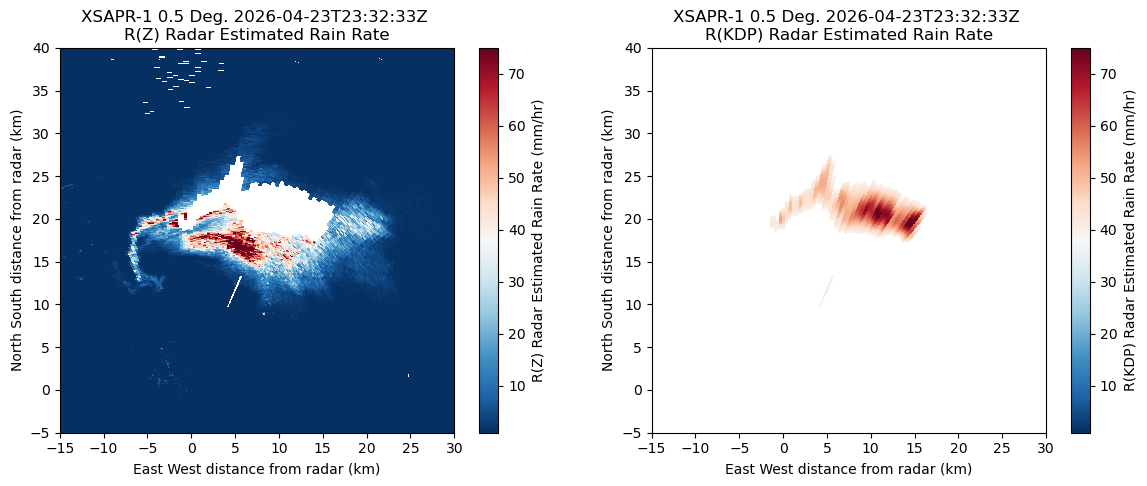

In [22]:
display = pyart.graph.RadarDisplay(radar)
# Generate matplotlib figure and axe array objects
fig, axarr = plt.subplots(1, 2, figsize=[14, 5])
plt.subplots_adjust(wspace=0.2, hspace=0.35)

# reflectivity
display.plot('rain_z', sweep=0, ax=axarr[0], cmap='RdBu_r', vmax=75, vmin=1)
axarr[0].set_xlim([-15, 30])
axarr[0].set_ylim([-5, 40])

# differential reflectivity
display.plot("rain_kdp", sweep=0, ax=axarr[1], cmap="RdBu_r", vmax=75, vmin=1)
axarr[1].set_xlim([-15, 30])
axarr[1].set_ylim([-5, 40])

## Combined Radar Estimated Rainfall Product

In [23]:
combined_data = np.where(~radar.fields["rain_z"]["data"].mask, 
                         radar.fields["rain_z"]["data"], 
                         radar.fields["rain_kdp"]["data"])
# Combine the masks using logical OR (mask where either is masked)
combined_mask = np.ma.mask_or(radar.fields["rain_z"]["data"].mask, 
                              radar.fields["rain_kdp"]["data"].mask)

# Merge data and apply the combined mask
merged = np.ma.array(combined_data, mask=combined_mask)

In [24]:
# define the dictionary structure for the rain rate data
rain = pyart.config.get_metadata("radar_estimated_rain_rate")
rain["long_name"] = "R(Z+KDP) Radar Estimated Rain Rate"
rain["standard_name"] = "R(Z+KDP) Radar Estimated Rain Rate"
rain["data"] = combined_data
# add the field back into the radar object
radar.add_field("rain_combined", rain, replace_existing=True)

(-5.0, 40.0)

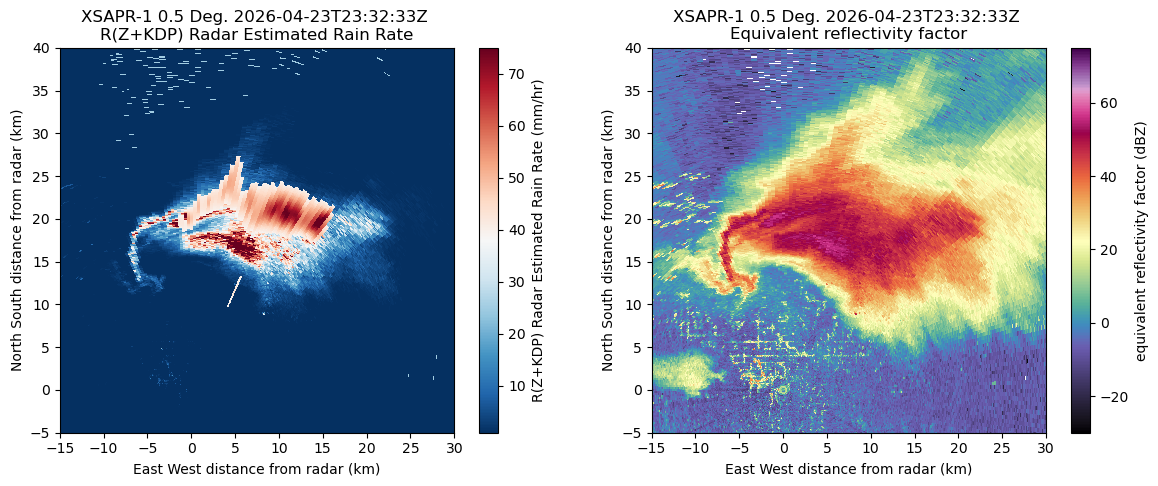

In [25]:
display = pyart.graph.RadarDisplay(radar)
# Generate matplotlib figure and axe array objects
fig, axarr = plt.subplots(1, 2, figsize=[14, 5])
plt.subplots_adjust(wspace=0.2, hspace=0.35)

# reflectivity
display.plot('rain_combined', sweep=0, ax=axarr[0], cmap='RdBu_r', vmax=75, vmin=1)
axarr[0].set_xlim([-15, 30])
axarr[0].set_ylim([-5, 40])
# reflectivity
display.plot('reflectivity', sweep=0, ax=axarr[1], cmap='ChaseSpectral')
axarr[1].set_xlim([-15, 30])
axarr[1].set_ylim([-5, 40])

## Create a Gridded QPE Product for Future Comparison with Model/MRMS

In [26]:
def sgp_grid(radar, 
             z_limits=(500., 15_000.), 
             y_limits=(-30_000., 30_000), 
             x_limits=(-30_000., 30_000),
             resolution=500
):
    """
    Function to create a Py-ART grid object from a given radar file

    Inputs
    ------
    radar : Py-ART radar object
        Py-ART radar object to create a grid object from
    z_limits : tuple
        vertical dimension grid limits
    y_limits : tuple
        longitude dimension grid limits
    x_limits : tuple
        latitude dimension grid limits
    resolution : float
        desired resolution of our grid object

    Calls
    -----
    compute_number_of_points
        compute number of gates in each direction

    Outputs
    -------
    grid : Py-ART Grid object
    """
    def compute_number_of_points(extent, resolution):
        return int((extent[1] - extent[0])/resolution)

    z_grid_points = compute_number_of_points(z_limits, resolution)
    x_grid_points = compute_number_of_points(x_limits, resolution)
    y_grid_points = compute_number_of_points(y_limits, resolution)
    print(z_grid_points)
    grid = pyart.map.grid_from_radars([radar],
                                      grid_shape=(z_grid_points,
                                                  y_grid_points,
                                                  x_grid_points),
                                      grid_limits=(z_limits,
                                                   y_limits,
                                                   x_limits),
    )

    return grid

In [27]:
grid = sgp_grid(radar)

29


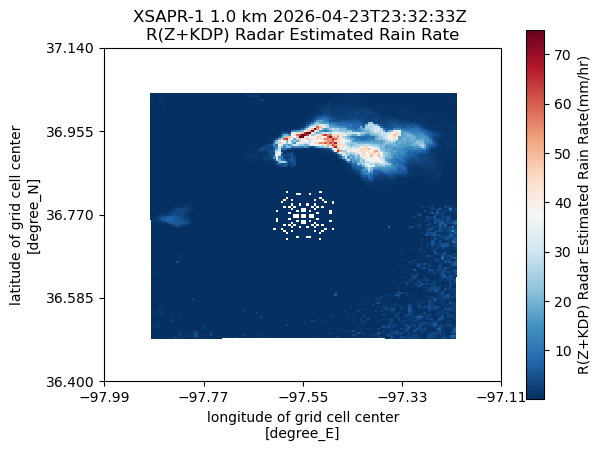

In [28]:
display = pyart.graph.GridMapDisplay(grid)
display.plot_grid('rain_combined',
                  level=1,
                  vmin=0.1,
                  vmax=75,
                  cmap='RdBu_r')

---
:::{admonition} Exercises for Students
We've explored calculating quantitative precipitation estimates (QPE) from ARM radar data 
and generated a gridded object (500m resolution) for comparison against other operational
products. 

With this [Multi-Radar Multi-Sensor (MRMS)](https://www.nssl.noaa.gov/projects/mrms/) [notebook from the ARM Bankhead National Forest facility](https://github.com/ARM-Development/bnf-radar-examples/blob/main/notebooks/bnf-mrms-qpe-hourly.ipynb), compare these rainfall estimates directly with MRMS
:::